# YOLO Model Training Template

Reusable notebook for training YOLO models on custom datasets.

## Workflow
| Step | Description |
|------|-------------|
| 0 | Environment setup & dependency check |
| 1 | Dataset loading & validation |
| 2 | Model initialization |
| 3 | Training pipeline |
| 4 | Evaluation & metrics |
| 5 | Weight export |
| 6 | Inference test on dummy data |

> **Note:** This notebook uses a small synthetic dummy dataset to validate the full pipeline end-to-end.

---
## Step 0 — Environment Setup

In [1]:
# Core imports
import os
import sys
import shutil
import random
import csv
import time
import numpy as np
import yaml
from pathlib import Path

# Deep learning
import torch
from ultralytics import YOLO

# Image utilities
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f'Python     : {sys.version.split()[0]}')
print(f'PyTorch    : {torch.__version__}')
cuda_info = 'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU-only'
print(f'CUDA       : {torch.cuda.is_available()} ({cuda_info})')

# Reproducibility seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Seeds set for reproducibility.')

Python     : 3.11.9
PyTorch    : 2.13.0+cpu
CUDA       : False (CPU-only)
Seeds set for reproducibility.


In [2]:
# Configuration -- edit these to point at your real dataset

# Paths (relative to this notebook's location)
NOTEBOOK_DIR   = Path('.').resolve()
DATASET_ROOT   = NOTEBOOK_DIR.parent / 'datasets' / 'dummy_dataset'
WEIGHTS_DIR    = NOTEBOOK_DIR.parent / 'weights'
RUNS_DIR       = NOTEBOOK_DIR.parent.parent / 'runs'

# Model
BASE_MODEL     = 'yolov8n.pt'              # nano -- fast for CPU smoke-tests
PROJECT_NAME   = 'skyguard'
RUN_NAME       = 'training_template_run'

# Training hyper-parameters
EPOCHS         = 3          # keep tiny for smoke-test; raise for real runs
IMG_SIZE       = 320        # small for speed; 640 for production
BATCH_SIZE     = 2          # 2 images per batch (dummy dataset is tiny)
DEVICE         = 'cpu'      # '0' for GPU, 'cpu' for CPU
WORKERS        = 0          # set >0 only on Linux/Mac

# Export formats
EXPORT_FORMATS = ['onnx']   # add 'torchscript', 'tflite', etc. as needed

print('Configuration loaded.')
print(f'  Dataset  : {DATASET_ROOT}')
print(f'  Weights  : {WEIGHTS_DIR}')
print(f'  Runs     : {RUNS_DIR}')

Configuration loaded.
  Dataset  : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset
  Weights  : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\weights
  Runs     : C:\Users\Padmaja Kachare\skyguard-ai\runs


---
## Step 1 — Dataset Loading

This section:
1. Generates a small **synthetic dummy dataset** (solid-colour images with bounding boxes) if no real dataset exists.
2. Validates the YOLO directory layout and `data.yaml`.
3. Reports dataset statistics and visualises sample images.

In [3]:
# 1a. Generate dummy dataset

def generate_dummy_dataset(dataset_root, num_images=10, img_size=320,
                           class_names=None, overwrite=False):
    """
    Generate a minimal YOLO-format dummy dataset with synthetic images.

    Directory layout produced:
        dataset_root/
            images/   *.jpg
            labels/   *.txt  (YOLO format: class cx cy w h -- all normalised 0-1)
            data.yaml
    """
    if class_names is None:
        class_names = ['drone', 'bird']

    images_dir = dataset_root / 'images'
    labels_dir = dataset_root / 'labels'
    yaml_path  = dataset_root / 'data.yaml'

    existing = list(images_dir.glob('*.jpg')) if images_dir.exists() else []
    if existing and not overwrite:
        print(f'[INFO] Dataset already contains {len(existing)} image(s). '
              'Set overwrite=True to regenerate.')
        return yaml_path

    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    BG_COLOURS  = [(30, 30, 50), (20, 60, 20), (80, 40, 10), (10, 30, 80)]
    BOX_COLOURS = [(255, 80, 80), (80, 255, 80), (80, 80, 255), (255, 220, 0)]

    for i in range(num_images):
        img  = Image.new('RGB', (img_size, img_size),
                         color=random.choice(BG_COLOURS))
        draw = ImageDraw.Draw(img)

        n_boxes     = random.randint(1, 3)
        label_lines = []
        for _ in range(n_boxes):
            cls = random.randint(0, len(class_names) - 1)
            bw  = random.randint(30, img_size // 3)
            bh  = random.randint(30, img_size // 3)
            x1  = random.randint(0, img_size - bw)
            y1  = random.randint(0, img_size - bh)
            x2, y2 = x1 + bw, y1 + bh
            draw.rectangle([x1, y1, x2, y2],
                           outline=random.choice(BOX_COLOURS), width=3)
            cx = (x1 + x2) / 2 / img_size
            cy = (y1 + y2) / 2 / img_size
            nw = bw / img_size
            nh = bh / img_size
            label_lines.append(f'{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}')

        fname = f'dummy_{i:04d}'
        img.save(images_dir / f'{fname}.jpg', quality=90)
        (labels_dir / f'{fname}.txt').write_text('\n'.join(label_lines))

    # Write data.yaml using absolute path so Ultralytics finds it from any cwd
    data_cfg = {
        'path' : str(dataset_root.resolve()),
        'train': 'images',
        'val'  : 'images',
        'names': {i: n for i, n in enumerate(class_names)},
    }
    with open(yaml_path, 'w') as f:
        yaml.dump(data_cfg, f, default_flow_style=False)

    print(f'[OK] Dummy dataset generated at: {dataset_root}')
    print(f'     {num_images} images | classes: {class_names}')
    return yaml_path


DATA_YAML = generate_dummy_dataset(
    dataset_root=DATASET_ROOT,
    num_images=10,
    img_size=IMG_SIZE,
    class_names=['drone', 'bird'],
    overwrite=True,
)
print(f'data.yaml  : {DATA_YAML}')

[OK] Dummy dataset generated at: C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset
     10 images | classes: ['drone', 'bird']
data.yaml  : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset\data.yaml


In [4]:
# 1b. Validate dataset layout

def validate_dataset(yaml_path):
    """Check that the dataset folder structure is YOLO-compatible."""
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)

    root       = Path(cfg['path'])
    train_imgs = root / cfg['train']
    val_imgs   = root / cfg['val']

    stats = {
        'yaml_path'   : str(yaml_path),
        'dataset_root': str(root),
        'classes'     : cfg['names'],
        'num_classes' : len(cfg['names']),
        'train_images': len(list(train_imgs.glob('*.jpg'))) +
                        len(list(train_imgs.glob('*.png'))),
        'val_images'  : len(list(val_imgs.glob('*.jpg')))   +
                        len(list(val_imgs.glob('*.png'))),
    }

    print('Dataset validation')
    print('-' * 40)
    for k, v in stats.items():
        print(f'  {k:<18}: {v}')

    assert stats['train_images'] > 0, 'No training images found!'
    assert stats['val_images']   > 0, 'No validation images found!'
    print('  Status             : PASSED')
    return stats


dataset_stats = validate_dataset(DATA_YAML)

Dataset validation
----------------------------------------
  yaml_path         : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset\data.yaml
  dataset_root      : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset
  classes           : {0: 'drone', 1: 'bird'}
  num_classes       : 2
  train_images      : 10
  val_images        : 10
  Status             : PASSED


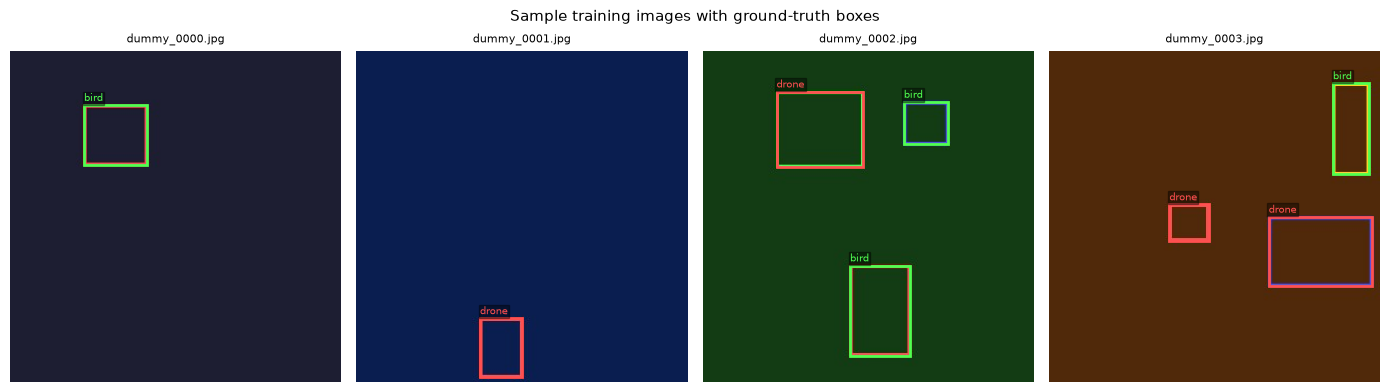

In [5]:
# 1c. Visualise sample images with ground-truth bounding boxes

CLASS_NAMES = list(dataset_stats['classes'].values())
COLOURS     = ['#FF5050', '#50FF50', '#5050FF', '#FFD700']

sample_imgs = sorted((DATASET_ROOT / 'images').glob('*.jpg'))[:4]

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(14, 4))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    img  = np.array(Image.open(img_path))
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

    label_path = DATASET_ROOT / 'labels' / (img_path.stem + '.txt')
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rect = mpatches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=COLOURS[cls_id % len(COLOURS)],
                facecolor='none',
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, CLASS_NAMES[cls_id],
                    color=COLOURS[cls_id % len(COLOURS)], fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

plt.suptitle('Sample training images with ground-truth boxes', fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 2 — Model Initialization

In [6]:
# 2. Load pre-trained YOLOv8 backbone

# Look for local weights first (already downloaded to notebooks/)
local_weights = NOTEBOOK_DIR / BASE_MODEL
weights_arg   = str(local_weights) if local_weights.exists() else BASE_MODEL

model = YOLO(weights_arg)

print('Model summary')
print('-' * 40)
print(f'  Architecture : {model.type}')
print(f'  Task         : {model.task}')
print(f'  Parameters   : {sum(p.numel() for p in model.model.parameters()):,}')
print(f'  Weights from : {weights_arg}')

Model summary
----------------------------------------
  Architecture : <bound method Module.type of YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32,

---
## Step 3 — Training Pipeline

In [7]:
# 3. Train

print('Starting training ...')
print(f'  Epochs     : {EPOCHS}')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Device     : {DEVICE}')
print(f'  data.yaml  : {DATA_YAML}')

t0 = time.time()

results = model.train(
    data     = str(DATA_YAML),
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    device   = DEVICE,
    workers  = WORKERS,
    project  = str(RUNS_DIR / PROJECT_NAME),
    name     = RUN_NAME,
    exist_ok = True,
    verbose  = True,
    augment  = False,
    plots    = False,
    save     = True,
)

elapsed = time.time() - t0
print(f'Training finished in {elapsed:.1f}s')

Starting training ...
  Epochs     : 3
  Image size : 320
  Batch size : 2
  Device     : cpu
  data.yaml  : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset\data.yaml


Ultralytics 8.4.112  Python-3.11.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12450HX)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\Padmaja Kachare\skyguard-ai\cv-model\notebooks\yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_te

Overriding model.yaml nc=80 with nc=2



                   from  n    params  module                                       arguments                     


...

                   all         10         19    0.00151        0.5    0.00383    0.00253


                 drone          6          7    0.00303          1    0.00767    0.00507


                  bird          8         12          0          0          0          0


Speed: 0.3ms preprocess, 35.3ms inference, 0.0ms loss, 1.2ms postprocess per image


Training finished in 11.8s


In [8]:
# 3b. Locate best weights produced by training

run_dir  = Path(results.save_dir)
best_pt  = run_dir / 'weights' / 'best.pt'
last_pt  = run_dir / 'weights' / 'last.pt'

print(f'Run directory : {run_dir}')
print(f'best.pt exists: {best_pt.exists()}')
print(f'last.pt exists: {last_pt.exists()}')

assert best_pt.exists() or last_pt.exists(), \
    'No weights found after training!'

TRAINED_WEIGHTS = best_pt if best_pt.exists() else last_pt
print(f'Using: {TRAINED_WEIGHTS}')

Run directory : C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run
best.pt exists: True
last.pt exists: True
Using: C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run\weights\best.pt


---
## Step 4 — Evaluation & Metrics

In [9]:
# 4a. Run validation with the trained model

eval_model = YOLO(str(TRAINED_WEIGHTS))

val_results = eval_model.val(
    data    = str(DATA_YAML),
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = DEVICE,
    workers = WORKERS,
    verbose = False,
    plots   = False,
)

box = val_results.box
metrics = {
    'mAP50'    : float(box.map50),
    'mAP50-95' : float(box.map),
    'Precision': float(box.mp),
    'Recall'   : float(box.mr),
}

print('Validation Metrics')
print('-' * 40)
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')

Ultralytics 8.4.112  Python-3.11.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12450HX)


Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 63.118.9 MB/s, size: 5.1 KB)


val: Scanning C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset\labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 1/5 2.7it/s 0.1s<1.5s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 60% ━━━━━━━───── 3/5 5.2it/s 0.3s<0.4s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.9it/s 0.5s

                   all         10         19    0.00151        0.5    0.00383    0.00253


Speed: 0.4ms preprocess, 38.5ms inference, 0.0ms loss, 2.2ms postprocess per image


Validation Metrics
----------------------------------------
  mAP50       : 0.0038
  mAP50-95    : 0.0025
  Precision   : 0.0015
  Recall      : 0.5000


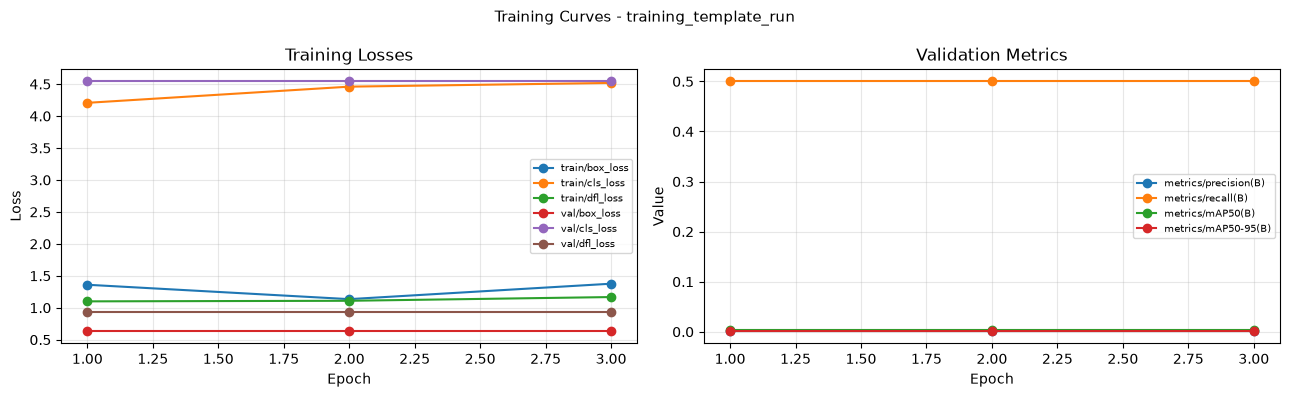

In [10]:
# 4b. Plot training loss curves from results.csv

csv_path = run_dir / 'results.csv'

if csv_path.exists():
    with open(csv_path, newline='') as f:
        reader   = csv.DictReader(f)
        csv_rows = list(reader)
        col_names = [c.strip() for c in reader.fieldnames]

    loss_cols   = [c for c in col_names if 'loss' in c.lower()]
    metric_cols = [c for c in col_names if any(
                   k in c.lower() for k in ['map', 'precision', 'recall'])]

    def col_values(rows, col):
        return [float(r[col]) for r in rows if col in r and r[col].strip()]

    epochs_axis = list(range(1, len(csv_rows) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    for col in loss_cols:
        vals = col_values(csv_rows, col)
        if vals:
            ax.plot(epochs_axis[:len(vals)], vals, label=col.strip(), marker='o')
    ax.set_title('Training Losses')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for col in metric_cols:
        vals = col_values(csv_rows, col)
        if vals:
            ax.plot(epochs_axis[:len(vals)], vals, label=col.strip(), marker='o')
    ax.set_title('Validation Metrics')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Value')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Training Curves - {RUN_NAME}', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('[WARN] results.csv not found -- skipping loss-curve plot.')

---
## Step 5 — Weight Export

In [11]:
# 5. Export trained model to deployment formats

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

exported_files = {}

for fmt in EXPORT_FORMATS:
    print(f"Exporting to '{fmt}' ...")
    try:
        export_path = eval_model.export(
            format   = fmt,
            imgsz    = IMG_SIZE,
            simplify = (fmt == 'onnx'),
        )
        if export_path:
            export_path = Path(export_path)
            dest = WEIGHTS_DIR / export_path.name
            shutil.copy2(export_path, dest)
            exported_files[fmt] = str(dest)
            print(f'  {fmt.upper()} -> {dest}  ({dest.stat().st_size / 1024:.1f} KB)')
        else:
            print(f"  Export returned no path for format '{fmt}'.")
    except Exception as exc:
        print(f"  Export failed for '{fmt}': {exc}")

# Also copy best.pt into weights/
pt_dest = WEIGHTS_DIR / f'{RUN_NAME}_best.pt'
shutil.copy2(TRAINED_WEIGHTS, pt_dest)
print(f'  PyTorch -> {pt_dest}  ({pt_dest.stat().st_size / 1024:.1f} KB)')
exported_files['pytorch'] = str(pt_dest)

print('\nExported weights')
print('-' * 40)
for fmt, path in exported_files.items():
    print(f'  {fmt:<12}: {path}')

Exporting to 'onnx' ...
Ultralytics 8.4.112  Python-3.11.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12450HX)



PyTorch: starting from 'C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (5.9 MB)



ONNX: starting export with onnx 1.22.0 opset 20...


ONNX: slimming with onnxslim 0.1.94...


ONNX: export success  1.7s, saved as 'C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run\weights\best.onnx' (11.6 MB)



Export complete (1.8s)
Results saved to C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run\weights\best.onnx
Predict:         yolo predict task=detect model=C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run\weights\best.onnx imgsz=320 
Validate:        yolo val task=detect model=C:\Users\Padmaja Kachare\skyguard-ai\runs\skyguard\training_template_run\weights\best.onnx imgsz=320 data=C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_dataset\data.yaml  
Visualize:       https://netron.app


  ONNX -> C:\Users\Padmaja Kachare\skyguard-ai\cv-model\weights\best.onnx  (11855.5 KB)
  PyTorch -> C:\Users\Padmaja Kachare\skyguard-ai\cv-model\weights\training_template_run_best.pt  (6058.7 KB)

Exported weights
----------------------------------------
  onnx        : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\weights\best.onnx
  pytorch     : C:\Users\Padmaja Kachare\skyguard-ai\cv-model\weights\training_template_run_best.pt


---
## Step 6 — Inference Test

Run the trained model on a set of unseen dummy images and visualise the predictions.

In [12]:
# 6a. Generate fresh test images (not used during training)

TEST_DIR = NOTEBOOK_DIR.parent / 'datasets' / 'dummy_test'
TEST_DIR.mkdir(parents=True, exist_ok=True)

NUM_TEST    = 4
test_images = []   # keep absolute Paths for visualisation

for i in range(NUM_TEST):
    img  = Image.new('RGB', (IMG_SIZE, IMG_SIZE),
                     color=(random.randint(0, 60),
                            random.randint(0, 60),
                            random.randint(0, 60)))
    draw = ImageDraw.Draw(img)
    for _ in range(random.randint(1, 3)):
        bw = random.randint(40, IMG_SIZE // 3)
        bh = random.randint(40, IMG_SIZE // 3)
        x1 = random.randint(0, IMG_SIZE - bw)
        y1 = random.randint(0, IMG_SIZE - bh)
        draw.rectangle([x1, y1, x1 + bw, y1 + bh],
                       outline=(random.randint(150, 255),
                                random.randint(150, 255),
                                random.randint(150, 255)),
                       width=3)
    p = TEST_DIR / f'test_{i:04d}.jpg'
    img.save(p, quality=90)
    test_images.append(p)   # store absolute Path

print(f'Generated {NUM_TEST} test images at: {TEST_DIR}')

Generated 4 test images at: C:\Users\Padmaja Kachare\skyguard-ai\cv-model\datasets\dummy_test


In [13]:
# 6b. Run inference

infer_model = YOLO(str(TRAINED_WEIGHTS))

predictions = infer_model.predict(
    source  = [str(p) for p in test_images],
    imgsz   = IMG_SIZE,
    conf    = 0.25,
    iou     = 0.45,
    device  = DEVICE,
    verbose = False,
    save    = False,
)

print(f'Inference complete on {len(predictions)} image(s).')
for i, pred in enumerate(predictions):
    n_det = len(pred.boxes) if pred.boxes is not None else 0
    print(f'  Image {i}: {n_det} detection(s)')

Inference complete on 4 image(s).
  Image 0: 0 detection(s)
  Image 1: 0 detection(s)
  Image 2: 0 detection(s)
  Image 3: 0 detection(s)


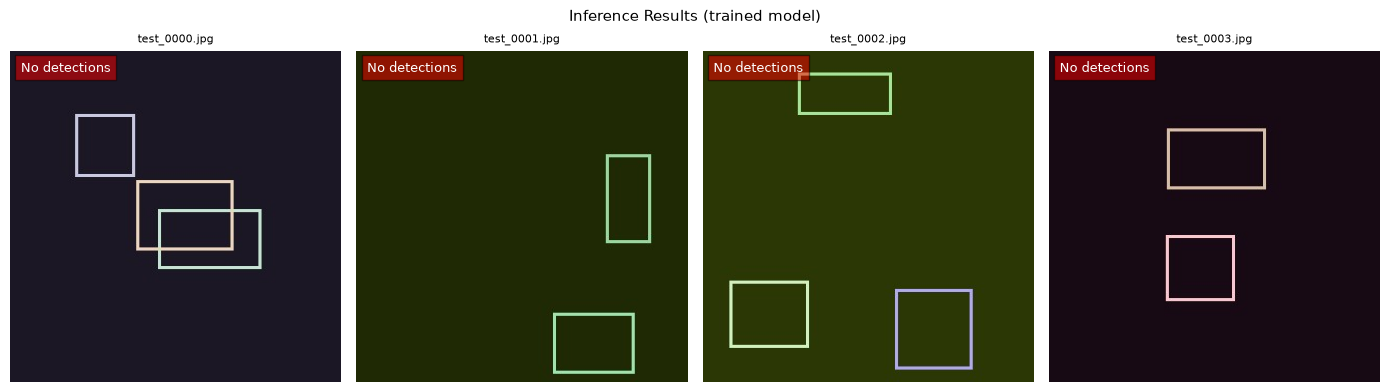

In [14]:
# 6c. Visualise predictions
# NOTE: pred.path is an Ultralytics-internal relative name ('image0.jpg'),
# so we zip test_images (absolute Paths) alongside predictions instead.

fig, axes = plt.subplots(1, len(predictions), figsize=(14, 4))
if len(predictions) == 1:
    axes = [axes]

for ax, (img_path, pred) in zip(axes, zip(test_images, predictions)):
    img_arr = np.array(Image.open(img_path))
    h, w    = img_arr.shape[:2]
    ax.imshow(img_arr)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

    if pred.boxes is not None and len(pred.boxes) > 0:
        for box in pred.boxes:
            xyxy   = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            x1, y1, x2, y2 = xyxy
            colour = COLOURS[cls_id % len(COLOURS)]
            rect   = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=colour, facecolor='none',
            )
            ax.add_patch(rect)
            cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
            ax.text(x1, y1 - 4, f'{cls_name} {conf:.2f}',
                    color=colour, fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))
    else:
        ax.text(10, 20, 'No detections', color='white', fontsize=9,
                bbox=dict(facecolor='red', alpha=0.5))

plt.suptitle('Inference Results (trained model)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

In [15]:
# Final summary

print('=' * 55)
print('  YOLO Training Pipeline - Run Summary')
print('=' * 55)
print(f'  Project      : {PROJECT_NAME}')
print(f'  Run name     : {RUN_NAME}')
print(f'  Architecture : {BASE_MODEL}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Image size   : {IMG_SIZE}')
print(f'  Device       : {DEVICE}')
print()
print('  Dataset')
print(f"    Train imgs : {dataset_stats['train_images']}")
print(f"    Val imgs   : {dataset_stats['val_images']}")
print(f"    Classes    : {dataset_stats['classes']}")
print()
print('  Validation Metrics')
for k, v in metrics.items():
    print(f'    {k:<12}: {v:.4f}')
print()
print('  Exported Weights')
for fmt, path in exported_files.items():
    size_kb = Path(path).stat().st_size / 1024
    print(f'    {fmt:<12}: {Path(path).name}  ({size_kb:.1f} KB)')
print('=' * 55)
print('  Pipeline completed successfully!')
print('=' * 55)

  YOLO Training Pipeline - Run Summary
  Project      : skyguard
  Run name     : training_template_run
  Architecture : yolov8n.pt
  Epochs       : 3
  Image size   : 320
  Device       : cpu

  Dataset
    Train imgs : 10
    Val imgs   : 10
    Classes    : {0: 'drone', 1: 'bird'}

  Validation Metrics
    mAP50       : 0.0038
    mAP50-95    : 0.0025
    Precision   : 0.0015
    Recall      : 0.5000

  Exported Weights
    onnx        : best.onnx  (11855.5 KB)
    pytorch     : training_template_run_best.pt  (6058.7 KB)
  Pipeline completed successfully!
